In [13]:
import os, cv2, shutil
import numpy as np
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 🔧 Paramètres
img_size = (128, 128)
epochs = 20
dataset_path = "/kaggle/input/skin-cancer-isic-images"
working_path = "/kaggle/working/cleaned_dataset"
FNFP_path = "/kaggle/working/FN_FP"
label_dict = {"benign": 0, "malignant": 1}

# 🧼 Préparer les dossiers
if os.path.exists(working_path): shutil.rmtree(working_path)
shutil.copytree(dataset_path, working_path)
os.makedirs(os.path.join(FNFP_path, "benign"), exist_ok=True)
os.makedirs(os.path.join(FNFP_path, "malignant"), exist_ok=True)

# 🧠 Calcule gradient
def compute_gradient(image):
    image = (image * 255).astype(np.uint8)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    grad_norm = cv2.normalize(grad_magnitude, None, 0, 1.0, cv2.NORM_MINMAX)
    return grad_norm

# 📥 Chargement des images avec gradient
def load_data_with_gradients(base_dir):
    X, X_grad, y, paths = [], [], [], []
    for label in ["benign", "malignant"]:
        folder = os.path.join(base_dir, label)
        for img_name in os.listdir(folder):
            path = os.path.join(folder, img_name)
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(img, img_size) / 255.0
                grad = compute_gradient(img)
                X.append(img)
                X_grad.append(np.expand_dims(grad, axis=-1))
                y.append(label_dict[label])
                paths.append(path)
    return np.array(X), np.array(X_grad), to_categorical(y, 2), paths


# ✅ Nouveau modèle image + gradient
def build_gradient_cnn(input_shape):
    input_img = Input(shape=input_shape, name="input_image")
    input_grad = Input(shape=(input_shape[0], input_shape[1], 1), name="input_gradient")

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.BatchNormalization()(x)

    g = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_grad)
    g = layers.BatchNormalization()(g)

    fusion = layers.Add()([x, g])
    fusion = layers.MaxPooling2D((2, 2))(fusion)

    fusion = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(fusion)
    fusion = layers.BatchNormalization()(fusion)
    fusion = layers.MaxPooling2D((2, 2))(fusion)

    fusion = layers.Flatten()(fusion)
    fusion = layers.Dense(128, activation='relu')(fusion)
    fusion = layers.BatchNormalization()(fusion)
    fusion = layers.Dropout(0.5)(fusion)

    output = layers.Dense(2, activation='softmax')(fusion)

    model = models.Model(inputs=[input_img, input_grad], outputs=output)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [14]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2637, 128, 128, 3), Labels: (2637, 2)
Test: (660, 128, 128, 3), Labels: (660, 2)


In [15]:
# 📊 Dictionnaire des erreurs
error_counter = defaultdict(int)

for run in range(3):
    print(f"\n🧠 Entraînement {run+1}/3")

    model = build_gradient_cnn((128, 128, 3))
    model.fit([X_train, X_train_grad], y_train,
              validation_data=([X_test, X_test_grad], y_test),
              epochs=epochs, batch_size=32,
              callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=0)],
              verbose=0)
    
    # ✅ Évaluation finale
    y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calcul des métriques
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred)
    test_recall = recall_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred)

    # Affichage des résultats
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Precision: {test_precision * 100:.2f}%")
    print(f"Test Recall: {test_recall * 100:.2f}%")
    print(f"Test F1-Score: {test_f1 * 100:.2f}%")

    for i in range(len(y_true)):
        if y_pred[i] != y_true[i]:
            error_counter[test_paths[i]] += 1



🧠 Entraînement 1/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       360
           1       0.81      0.81      0.81       300

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.83      0.83      0.83       660


Test Accuracy: 82.73%
Test Precision: 81.00%
Test Recall: 81.00%
Test F1-Score: 81.00%

🧠 Entraînement 2/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       360
           1       0.80      0.83      0.82       300

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.83      0.83      0.83       660


Test Accuracy: 83.18%
Test Precision: 80.39%
Test Recall: 83.33%
Test F1-Score: 81.83%

🧠

In [16]:
removed = 0

for path in list(error_counter.keys()):
    if error_counter[path] >= 3 and os.path.exists(path):
        
        # 🏷️ Déduire le label à partir du chemin
        if "benign" in path.lower():
            label = "benign"
        elif "malignant" in path.lower():
            label = "malignant"
        else:
            continue  # Si on ne peut pas identifier la classe, on ignore

        # 💾 Sauvegarder dans le dossier FN_FP approprié
        dest_path = os.path.join(FNFP_path, label, os.path.basename(path))
        shutil.copy(path, dest_path)

        # 🗑️ Supprimer de la base nettoyée
        os.remove(path)
        removed += 1

print(f"\n🧹 {removed} images mal classées 3 fois ont été supprimées de {working_path}.")
print(f"📁 Et sauvegardées dans : {FNFP_path}/benign et {FNFP_path}/malignant")



🧹 75 images mal classées 3 fois ont été supprimées de /kaggle/working/cleaned_dataset.
📁 Et sauvegardées dans : /kaggle/working/FN_FP/benign et /kaggle/working/FN_FP/malignant


In [17]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2577, 128, 128, 3), Labels: (2577, 2)
Test: (645, 128, 128, 3), Labels: (645, 2)


In [18]:
# 📊 Dictionnaire des erreurs
error_counter = defaultdict(int)

for run in range(3):
    print(f"\n🧠 Entraînement {run+1}/3")

    model = build_gradient_cnn((128, 128, 3))
    model.fit([X_train, X_train_grad], y_train,
              validation_data=([X_test, X_test_grad], y_test),
              epochs=epochs, batch_size=32,
              callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=0)],
              verbose=0)
    
    # ✅ Évaluation finale
    y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calcul des métriques
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred)
    test_recall = recall_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred)

    # Affichage des résultats
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Precision: {test_precision * 100:.2f}%")
    print(f"Test Recall: {test_recall * 100:.2f}%")
    print(f"Test F1-Score: {test_f1 * 100:.2f}%")

    for i in range(len(y_true)):
        if y_pred[i] != y_true[i]:
            error_counter[test_paths[i]] += 1



🧠 Entraînement 1/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       352
           1       0.83      0.91      0.87       293

    accuracy                           0.87       645
   macro avg       0.87      0.88      0.87       645
weighted avg       0.88      0.87      0.87       645


Test Accuracy: 87.29%
Test Precision: 82.87%
Test Recall: 90.78%
Test F1-Score: 86.64%

🧠 Entraînement 2/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       352
           1       0.85      0.88      0.86       293

    accuracy                           0.87       645
   macro avg       0.87      0.87      0.87       645
weighted avg       0.88      0.87      0.87       645


Test Accuracy: 87.44%
Test Precision: 84.87%
Test Recall: 88.05%
Test F1-Score: 86.43%

🧠

In [19]:
removed = 0

for path in list(error_counter.keys()):
    if error_counter[path] >= 3 and os.path.exists(path):
        
        # 🏷️ Déduire le label à partir du chemin
        if "benign" in path.lower():
            label = "benign"
        elif "malignant" in path.lower():
            label = "malignant"
        else:
            continue  # Si on ne peut pas identifier la classe, on ignore

        # 💾 Sauvegarder dans le dossier FN_FP approprié
        dest_path = os.path.join(FNFP_path, label, os.path.basename(path))
        shutil.copy(path, dest_path)

        # 🗑️ Supprimer de la base nettoyée
        os.remove(path)
        removed += 1

print(f"\n🧹 {removed} images mal classées 3 fois ont été supprimées de {working_path}.")
print(f"📁 Et sauvegardées dans : {FNFP_path}/benign et {FNFP_path}/malignant")



🧹 55 images mal classées 3 fois ont été supprimées de /kaggle/working/cleaned_dataset.
📁 Et sauvegardées dans : /kaggle/working/FN_FP/benign et /kaggle/working/FN_FP/malignant


In [20]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2533, 128, 128, 3), Labels: (2533, 2)
Test: (634, 128, 128, 3), Labels: (634, 2)


In [21]:
# 📊 Dictionnaire des erreurs
error_counter = defaultdict(int)

for run in range(3):
    print(f"\n🧠 Entraînement {run+1}/3")

    model = build_gradient_cnn((128, 128, 3))
    model.fit([X_train, X_train_grad], y_train,
              validation_data=([X_test, X_test_grad], y_test),
              epochs=epochs, batch_size=32,
              callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=0)],
              verbose=0)
    
    # ✅ Évaluation finale
    y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calcul des métriques
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred)
    test_recall = recall_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred)

    # Affichage des résultats
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Precision: {test_precision * 100:.2f}%")
    print(f"Test Recall: {test_recall * 100:.2f}%")
    print(f"Test F1-Score: {test_f1 * 100:.2f}%")

    for i in range(len(y_true)):
        if y_pred[i] != y_true[i]:
            error_counter[test_paths[i]] += 1



🧠 Entraînement 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       345
           1       0.83      0.89      0.86       289

    accuracy                           0.87       634
   macro avg       0.86      0.87      0.87       634
weighted avg       0.87      0.87      0.87       634


Test Accuracy: 86.59%
Test Precision: 83.12%
Test Recall: 88.58%
Test F1-Score: 85.76%

🧠 Entraînement 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       345
           1       0.84      0.90      0.87       289

    accuracy                           0.88       634
   macro avg       0.88      0.88      0.88       634
weighted avg       0.88      0.88      0.88       634


Test Accuracy: 87.85%
Test Precision: 84.19%
Test Recall: 90.31%
Test F1-Score: 87.15%

🧠

In [22]:
removed = 0

for path in list(error_counter.keys()):
    if error_counter[path] >= 3 and os.path.exists(path):
        
        # 🏷️ Déduire le label à partir du chemin
        if "benign" in path.lower():
            label = "benign"
        elif "malignant" in path.lower():
            label = "malignant"
        else:
            continue  # Si on ne peut pas identifier la classe, on ignore

        # 💾 Sauvegarder dans le dossier FN_FP approprié
        dest_path = os.path.join(FNFP_path, label, os.path.basename(path))
        shutil.copy(path, dest_path)

        # 🗑️ Supprimer de la base nettoyée
        os.remove(path)
        removed += 1

print(f"\n🧹 {removed} images mal classées 3 fois ont été supprimées de {working_path}.")
print(f"📁 Et sauvegardées dans : {FNFP_path}/benign et {FNFP_path}/malignant")



🧹 57 images mal classées 3 fois ont été supprimées de /kaggle/working/cleaned_dataset.
📁 Et sauvegardées dans : /kaggle/working/FN_FP/benign et /kaggle/working/FN_FP/malignant


In [23]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2488, 128, 128, 3), Labels: (2488, 2)
Test: (622, 128, 128, 3), Labels: (622, 2)


In [24]:
# 📊 Dictionnaire des erreurs
error_counter = defaultdict(int)

for run in range(3):
    print(f"\n🧠 Entraînement {run+1}/3")

    model = build_gradient_cnn((128, 128, 3))
    model.fit([X_train, X_train_grad], y_train,
              validation_data=([X_test, X_test_grad], y_test),
              epochs=epochs, batch_size=32,
              callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=0)],
              verbose=0)
    
    # ✅ Évaluation finale
    y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calcul des métriques
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred)
    test_recall = recall_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred)

    # Affichage des résultats
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Precision: {test_precision * 100:.2f}%")
    print(f"Test Recall: {test_recall * 100:.2f}%")
    print(f"Test F1-Score: {test_f1 * 100:.2f}%")

    for i in range(len(y_true)):
        if y_pred[i] != y_true[i]:
            error_counter[test_paths[i]] += 1



🧠 Entraînement 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       337
           1       0.88      0.91      0.89       285

    accuracy                           0.90       622
   macro avg       0.90      0.90      0.90       622
weighted avg       0.90      0.90      0.90       622


Test Accuracy: 90.03%
Test Precision: 87.80%
Test Recall: 90.88%
Test F1-Score: 89.31%

🧠 Entraînement 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       337
           1       0.85      0.91      0.88       285

    accuracy                           0.89       622
   macro avg       0.88      0.89      0.89       622
weighted avg       0.89      0.89      0.89       622


Test Accuracy: 88.59%
Test Precision: 85.43%
Test Recall: 90.53%
Test F1-Score: 87.90%

🧠

In [25]:
removed = 0

for path in list(error_counter.keys()):
    if error_counter[path] >= 3 and os.path.exists(path):
        
        # 🏷️ Déduire le label à partir du chemin
        if "benign" in path.lower():
            label = "benign"
        elif "malignant" in path.lower():
            label = "malignant"
        else:
            continue  # Si on ne peut pas identifier la classe, on ignore

        # 💾 Sauvegarder dans le dossier FN_FP approprié
        dest_path = os.path.join(FNFP_path, label, os.path.basename(path))
        shutil.copy(path, dest_path)

        # 🗑️ Supprimer de la base nettoyée
        os.remove(path)
        removed += 1

print(f"\n🧹 {removed} images mal classées 3 fois ont été supprimées de {working_path}.")
print(f"📁 Et sauvegardées dans : {FNFP_path}/benign et {FNFP_path}/malignant")



🧹 43 images mal classées 3 fois ont été supprimées de /kaggle/working/cleaned_dataset.
📁 Et sauvegardées dans : /kaggle/working/FN_FP/benign et /kaggle/working/FN_FP/malignant


In [26]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2453, 128, 128, 3), Labels: (2453, 2)
Test: (614, 128, 128, 3), Labels: (614, 2)


In [27]:
# 📊 Dictionnaire des erreurs
error_counter = defaultdict(int)

for run in range(3):
    print(f"\n🧠 Entraînement {run+1}/3")

    model = build_gradient_cnn((128, 128, 3))
    model.fit([X_train, X_train_grad], y_train,
              validation_data=([X_test, X_test_grad], y_test),
              epochs=epochs, batch_size=32,
              callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=0)],
              verbose=0)
    
    # ✅ Évaluation finale
    y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calcul des métriques
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred)
    test_recall = recall_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred)

    # Affichage des résultats
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Precision: {test_precision * 100:.2f}%")
    print(f"Test Recall: {test_recall * 100:.2f}%")
    print(f"Test F1-Score: {test_f1 * 100:.2f}%")

    for i in range(len(y_true)):
        if y_pred[i] != y_true[i]:
            error_counter[test_paths[i]] += 1



🧠 Entraînement 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       332
           1       0.88      0.90      0.89       282

    accuracy                           0.90       614
   macro avg       0.90      0.90      0.90       614
weighted avg       0.90      0.90      0.90       614


Test Accuracy: 89.90%
Test Precision: 87.93%
Test Recall: 90.43%
Test F1-Score: 89.16%

🧠 Entraînement 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       332
           1       0.87      0.93      0.90       282

    accuracy                           0.90       614
   macro avg       0.90      0.90      0.90       614
weighted avg       0.90      0.90      0.90       614


Test Accuracy: 90.23%
Test Precision: 87.00%
Test Recall: 92.55%
Test F1-Score: 89.69%

🧠

In [28]:
removed = 0

for path in list(error_counter.keys()):
    if error_counter[path] >= 3 and os.path.exists(path):
        
        # 🏷️ Déduire le label à partir du chemin
        if "benign" in path.lower():
            label = "benign"
        elif "malignant" in path.lower():
            label = "malignant"
        else:
            continue  # Si on ne peut pas identifier la classe, on ignore

        # 💾 Sauvegarder dans le dossier FN_FP approprié
        dest_path = os.path.join(FNFP_path, label, os.path.basename(path))
        shutil.copy(path, dest_path)

        # 🗑️ Supprimer de la base nettoyée
        os.remove(path)
        removed += 1

print(f"\n🧹 {removed} images mal classées 3 fois ont été supprimées de {working_path}.")
print(f"📁 Et sauvegardées dans : {FNFP_path}/benign et {FNFP_path}/malignant")



🧹 36 images mal classées 3 fois ont été supprimées de /kaggle/working/cleaned_dataset.
📁 Et sauvegardées dans : /kaggle/working/FN_FP/benign et /kaggle/working/FN_FP/malignant


In [29]:
# 📦 Charger les données
X, X_grad, y, paths = load_data_with_gradients(working_path)

# 🔀 Division une seule fois
X_train, X_test, X_train_grad, X_test_grad, y_train, y_test, train_paths, test_paths = train_test_split(
    X, X_grad, y, paths, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")


Train: (2424, 128, 128, 3), Labels: (2424, 2)
Test: (607, 128, 128, 3), Labels: (607, 2)


In [30]:
X_fnfp, X_fnfp_grad, y_fnfp, _ = load_data_with_gradients(FNFP_path)

print(f"\n📦 Nombre d'images récupérées depuis FN_FP : {X_fnfp.shape[0]}")

# 🔗 Fusion avec les données d'entraînement
X_train = np.concatenate([X_train, X_fnfp])
X_train_grad = np.concatenate([X_train_grad, X_fnfp_grad])
y_train = np.concatenate([y_train, y_fnfp])


print(f"\n🧠 Nouvelle taille de X_train : {X_train.shape}")
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")

X_train = np.concatenate([X_train, X_fnfp])
X_train_grad = np.concatenate([X_train_grad, X_fnfp_grad])
y_train = np.concatenate([y_train, y_fnfp])



📦 Nombre d'images récupérées depuis FN_FP : 311

🧠 Nouvelle taille de X_train : (2735, 128, 128, 3)
Train: (2735, 128, 128, 3), Labels: (2735, 2)


In [31]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# 🔁 Réentraînement sur base enrichie
model = build_gradient_cnn((128, 128, 3))

# 📌 Callbacks
checkpoint = ModelCheckpoint(
    "best_model.keras", 
    monitor="val_accuracy", 
    save_best_only=True, 
    mode="max", 
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", 
    patience=3, 
    factor=0.2, 
    verbose=1
)

history = model.fit(
    [X_train, X_train_grad], y_train,
    validation_data=([X_test, X_test_grad], y_test),
    epochs=epochs,
    batch_size=32,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

# 🔄 Charger le meilleur modèle sauvegardé
from tensorflow.keras.models import load_model
model = load_model("best_model.keras")

# ✅ Accuracies finales
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# ✅ Évaluation finale
y_pred = np.argmax(model.predict([X_test, X_test_grad]), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n📋 Final Classification Report:")
print(classification_report(y_true, y_pred))

print(f"\n🎯 Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"🎯 Test Precision: {precision_score(y_true, y_pred) * 100:.2f}%")
print(f"🎯 Test Recall: {recall_score(y_true, y_pred) * 100:.2f}%")
print(f"🎯 Test F1-Score: {f1_score(y_true, y_pred) * 100:.2f}%")


Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6676 - loss: 1.0402
Epoch 1: val_accuracy improved from -inf to 0.57825, saving model to best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.6677 - loss: 1.0376 - val_accuracy: 0.5783 - val_loss: 0.6349 - learning_rate: 0.0010
Epoch 2/20
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7354 - loss: 0.5508
Epoch 2: val_accuracy did not improve from 0.57825
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7355 - loss: 0.5509 - val_accuracy: 0.5189 - val_loss: 0.6750 - learning_rate: 0.0010
Epoch 3/20
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7642 - loss: 0.4719
Epoch 3: val_accuracy improved from 0.57825 to 0.61285, saving model to best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7644 - loss: 0.4715 - val_accuracy: 0.6129 - val_loss: 0.8282 - learning_rate: 0.0010
Epoch 4/20
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8146 - loss: 0.3873
Epoch 4: val_

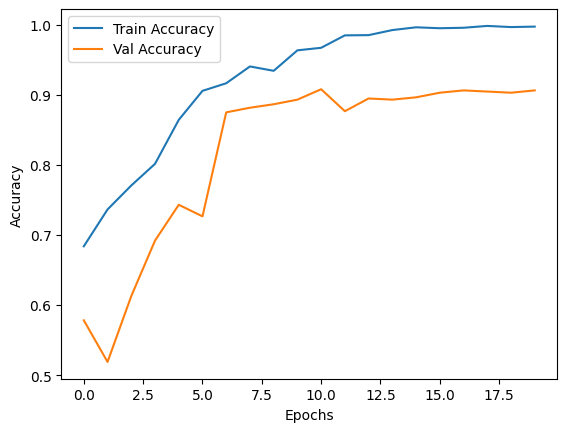

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Sauvegarde de l'image
plt.savefig('accuracy_curve.png', dpi=300, bbox_inches='tight')

plt.show()
